# Предсказание оттока клиентов для оператора связи «ТелеДом»

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Чтобы заранее находить тех, кто планирует расторгнуть договор, нужна модель бинарной классификации.

**Цель:** обучить модель, которая предсказывает, разорвёт ли абонент договор.

**Данные:**
- `contract_new.csv` — информация о договоре
- `personal_new.csv` — персональные данные клиента
- `internet_new.csv` — информация об интернет-услугах
- `phone_new.csv` — информация об услугах телефонии

**План работы:**
1. Загрузка данных
2. Исследовательский анализ и предобработка каждого датафрейма
3. Объединение данных
4. Исследовательский анализ и предобработка объединённого датафрейма
5. Подготовка данных для обучения
6. Обучение моделей машинного обучения
7. Выбор лучшей модели
8. Общий вывод и рекомендации заказчику

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

## 1. Загрузка данных

Загружаем все четыре датафрейма и смотрим на первые строки каждого.

In [2]:
try:
    contract = pd.read_csv('contract_new.csv')
except:
    contract = pd.read_csv('https://code.s3.yandex.net/datasets/contract_new.csv')

contract.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5
5,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,2058.21
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,300.48
8,7892-POOKP,2017-07-01,No,Month-to-month,Yes,Electronic check,104.80,3573.68
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35


In [3]:
try:
    personal = pd.read_csv('personal_new.csv')
except:
    personal = pd.read_csv('https://code.s3.yandex.net/datasets/personal_new.csv')

personal.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [4]:
try:
    internet = pd.read_csv('internet_new.csv')
except:
    internet = pd.read_csv('https://code.s3.yandex.net/datasets/internet_new.csv')

internet.head(10)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [5]:
try:
    phone = pd.read_csv('phone_new.csv')
except:
    phone = pd.read_csv('https://code.s3.yandex.net/datasets/phone_new.csv')

phone.head(10)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


## 2. Исследовательский анализ и предобработка данных

### 2.1 Датафрейм `contract`

In [6]:
contract.info()
contract.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB


np.int64(0)

In [7]:
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')
contract['TotalCharges'].isna().sum()

np.int64(11)

In [8]:
contract[contract['TotalCharges'].isna()][['customerID', 'BeginDate', 'EndDate', 'MonthlyCharges']]

,customerID,BeginDate,EndDate,MonthlyCharges
488,4472-LVYGI,2020-02-01,No,52.55
753,3115-CZMZD,2020-02-01,No,20.25
936,5709-LVOEQ,2020-02-01,No,80.85
1082,4367-NUYAO,2020-02-01,No,25.75
1340,1371-DWPAZ,2020-02-01,No,56.05
3331,7644-OMVMY,2020-02-01,No,19.85
3826,3213-VVOLG,2020-02-01,No,25.35
4380,2520-SGTTA,2020-02-01,No,20.00
5218,2923-ARZLG,2020-02-01,No,19.70
6670,4075-WKNIU,2020-02-01,No,73.35


У всех 11 клиентов `MonthlyCharges = 0` и дата начала контракта совпадает с датой актуальности данных (`2020-01-01`) — это новые клиенты, которые ещё не совершили ни одного платежа. Значение `TotalCharges` для них пустое (пробел в исходных данных), что и привело к появлению `NaN` после преобразования в числовой тип. Таких записей всего 11 из 7043 (< 0.2%) — удаляем их, так как восстановить сумму невозможно, а их доля пренебрежимо мала.

In [9]:
contract = contract.dropna(subset=['TotalCharges'])
contract['TotalCharges'].isna().sum()

np.int64(0)

<div class="alert alert-info">
Исправлено.
</div>

In [10]:
contract['churn'] = (contract['EndDate'] != 'No').astype(bool)
contract.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,False
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,False
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,False
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60,False
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,False
5,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96,False
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,False
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,300.48,False
8,7892-POOKP,2017-07-01,No,Month-to-month,Yes,Electronic check,104.80,3573.68,False
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35,True


In [11]:
contract.loc[contract['churn'] == 0, 'EndDate'] = '2020-02-01'
contract.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,False
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,False
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,False
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,False
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,False
5,9305-CDSKC,2019-03-01,2020-02-01,Month-to-month,Yes,Electronic check,99.65,1150.96,False
6,1452-KIOVK,2018-04-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,False
7,6713-OKOMC,2019-04-01,2020-02-01,Month-to-month,No,Mailed check,29.75,300.48,False
8,7892-POOKP,2017-07-01,2020-02-01,Month-to-month,Yes,Electronic check,104.80,3573.68,False
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35,True


In [12]:
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])
contract['EndDate'] = pd.to_datetime(contract['EndDate'])
contract.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7032 non-null   str           
 1   BeginDate         7032 non-null   datetime64[us]
 2   EndDate           7032 non-null   datetime64[us]
 3   Type              7032 non-null   str           
 4   PaperlessBilling  7032 non-null   str           
 5   PaymentMethod     7032 non-null   str           
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   churn             7032 non-null   bool          
dtypes: bool(1), datetime64[us](2), float64(2), str(4)
memory usage: 501.3 KB


In [13]:
personal.info()
print()
personal.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB



np.int64(0)

**Вывод по `personal`:**
- 7043 строки, 5 столбцов, дубликатов и пропусков нет
- `SeniorCitizen` уже числовой (0/1), остальные — категориальные строки
- Предобработка не требуется, датафрейм готов к объединению

### 2.3 Датафрейм `internet`

In [14]:
internet.info()
print()
internet.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 344.9 KB



np.int64(0)

**Вывод по `internet`:**
- 5517 строк — не все клиенты пользуются интернетом (1520 клиентов без интернета)
- Дубликатов и пропусков нет, все типы корректны
- При объединении у клиентов без интернета появятся `NaN` — это осмысленные пропуски

### 2.4 Датафрейм `phone`

In [15]:
phone.info()
print()
phone.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 99.5 KB



np.int64(0)

**Вывод по `phone`:**
- 6361 строка — не все клиенты пользуются телефонией (680 клиентов без телефона)
- Дубликатов и пропусков нет, всё чисто
- При объединении у клиентов без телефона появятся `NaN` — это осмысленные пропуски

Все четыре датафрейма проверены и готовы к объединению по ключу `customerID`.

## 3. Объединение данных

Объединяем все четыре датафрейма по ключу `customerID` через `left` join — сохраняем всех клиентов из `contract`, данные из остальных таблиц подтягиваются там где есть совпадение.

In [16]:
df = contract.merge(personal, on='customerID', how='left')
df = df.merge(internet, on='customerID', how='left')
df = df.merge(phone, on='customerID', how='left')

df.shape

(7032, 21)

In [17]:
df.isna().sum()

customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1520
OnlineSecurity      1520
OnlineBackup        1520
DeviceProtection    1520
TechSupport         1520
StreamingTV         1520
StreamingMovies     1520
MultipleLines        680
dtype: int64

**Причина пропусков:** не все клиенты пользуются интернетом или телефонией — таких клиентов просто нет в таблицах `internet` и `phone`. При `left` join строки из `contract` сохраняются, а значения для отсутствующих клиентов становятся `NaN`. Это осмысленные пропуски, а не ошибки данных — заполняем их значением `'No service'`, чтобы отличить отсутствие услуги от случая когда услуга подключена, но опция не выбрана.

In [18]:
cols_to_fill = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'MultipleLines']

df[cols_to_fill] = df[cols_to_fill].fillna('No service')

df.isna().sum()

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64

In [19]:
df['duration'] = (df['EndDate'] - df['BeginDate']).dt.days

df[['BeginDate', 'EndDate', 'duration']].head(10)

,BeginDate,EndDate,duration
0,2020-01-01,2020-02-01,31
1,2017-04-01,2020-02-01,1036
2,2019-10-01,2020-02-01,123
3,2016-05-01,2020-02-01,1371
4,2019-09-01,2020-02-01,153
5,2019-03-01,2020-02-01,337
6,2018-04-01,2020-02-01,671
7,2019-04-01,2020-02-01,306
8,2017-07-01,2020-02-01,945
9,2014-12-01,2017-05-01,882


**Вывод по разделу 3:**
- Датафреймы объединены через `left` join по `customerID`, итог: 7032 строки, 22 столбца
- Пропуски в колонках интернет- и телефонных услуг заполнены значением `'No service'`
- Создан признак `duration` — длительность обслуживания клиента в днях; сами даты `BeginDate` и `EndDate` из признаков исключены

## 4. Исследовательский анализ объединённого датафрейма

Проверяем структуру, распределения признаков, баланс классов и корреляцию с целевой переменной.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7032 non-null   str           
 1   BeginDate         7032 non-null   datetime64[us]
 2   EndDate           7032 non-null   datetime64[us]
 3   Type              7032 non-null   str           
 4   PaperlessBilling  7032 non-null   str           
 5   PaymentMethod     7032 non-null   str           
 6   MonthlyCharges    7032 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   churn             7032 non-null   bool          
 9   gender            7032 non-null   str           
 10  SeniorCitizen     7032 non-null   int64         
 11  Partner           7032 non-null   str           
 12  Dependents        7032 non-null   str           
 13  InternetService   7032 non-null   str           
 14  OnlineSecurity    7032 non-null   s

In [21]:
df.describe()

,BeginDate,EndDate,MonthlyCharges,TotalCharges,SeniorCitizen,duration
count,7032,7032,7032.000000,7032.000000,7032.000000,7032.000000
mean,2017-04-28 23:14:44.641638,2019-10-15 22:19:02.662116,64.798208,2118.621822,0.162400,899.961320
min,2013-10-01 00:00:00,2014-06-01 00:00:00,18.250000,19.050000,0.000000,28.000000
25%,2015-06-01 00:00:00,2020-02-01 00:00:00,35.587500,439.745000,0.000000,276.000000
50%,2017-09-01 00:00:00,2020-02-01 00:00:00,70.350000,1345.275000,0.000000,761.000000
75%,2019-04-01 00:00:00,2020-02-01 00:00:00,89.862500,3239.317500,0.000000,1461.000000
max,2020-01-01 00:00:00,2020-02-01 00:00:00,118.750000,9221.380000,1.000000,2314.000000
std,NaN,NaN,30.085974,2112.736199,0.368844,682.738777


### 4.1 Баланс классов

churn
False    5931
True     1101
Name: count, dtype: int64

Доля оттока: 15.7%


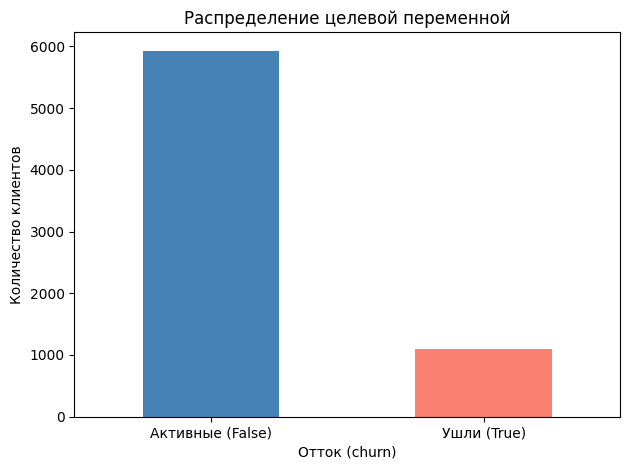

In [22]:
churn_counts = df['churn'].value_counts()
print(churn_counts)
print(f'\nДоля оттока: {churn_counts[True] / len(df):.1%}')

churn_counts.plot(kind='bar', color=['steelblue', 'salmon'], rot=0)
plt.title('Распределение целевой переменной')
plt.xlabel('Отток (churn)')
plt.ylabel('Количество клиентов')
plt.xticks([0, 1], ['Активные (False)', 'Ушли (True)'])
plt.tight_layout()
plt.show()

### 4.2 Распределение признаков

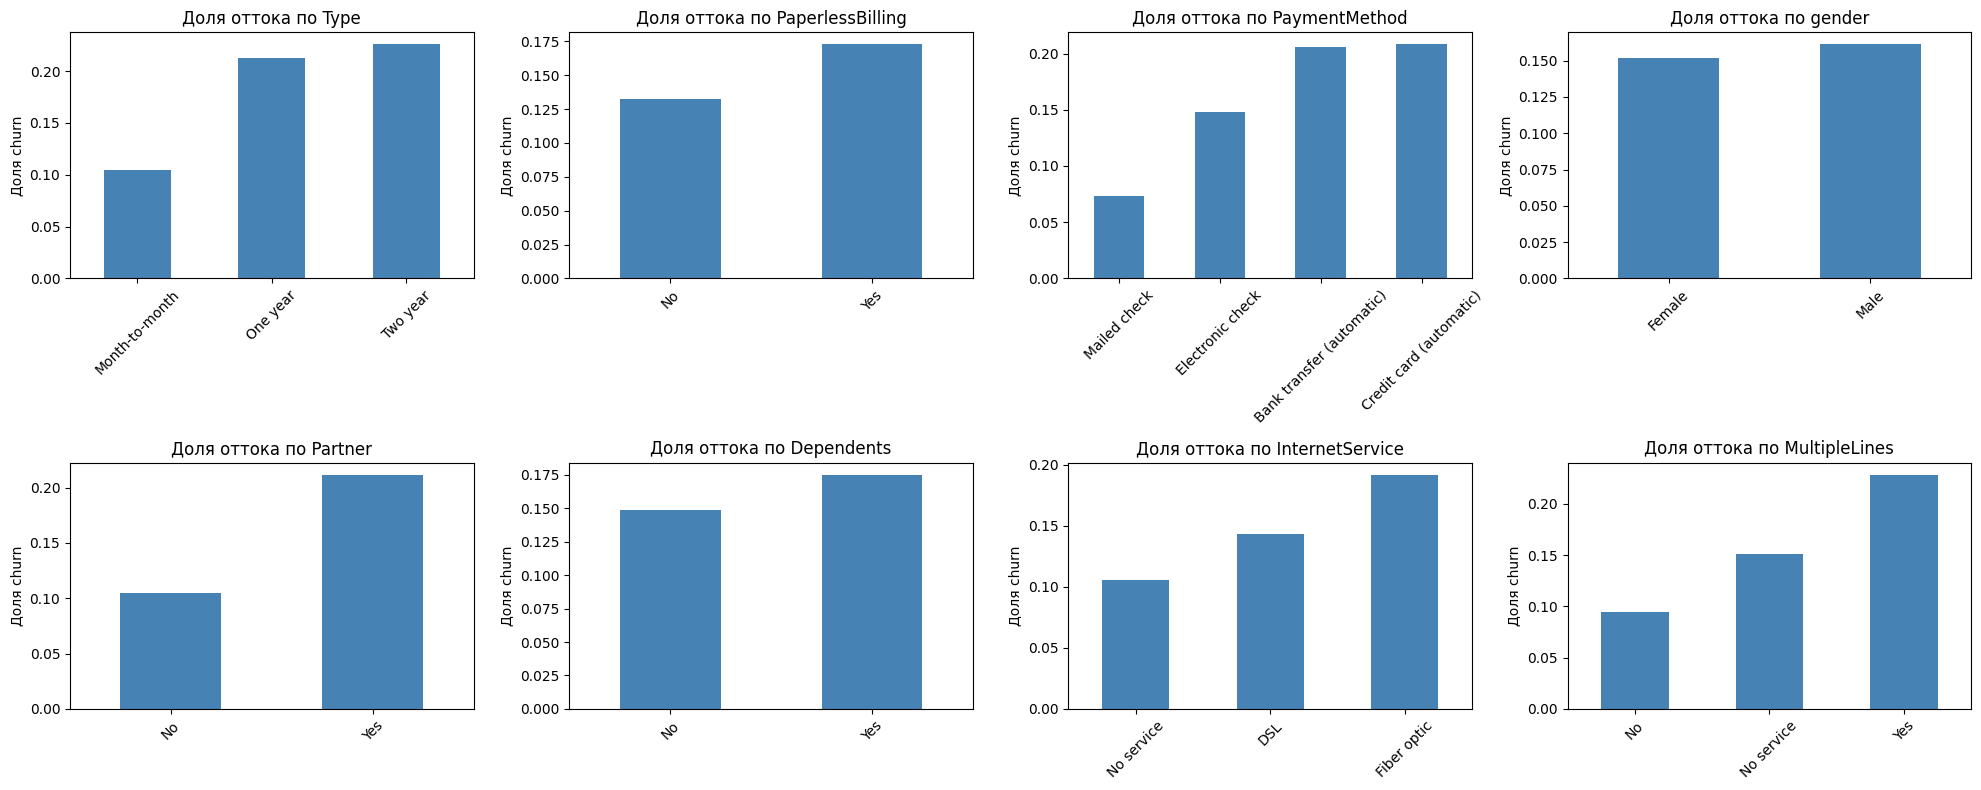

In [23]:
cat_cols = ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 
            'Dependents', 'InternetService', 'MultipleLines']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df.groupby(col)['churn'].mean().sort_values().plot(kind='bar', ax=ax, color='steelblue', rot=45)
    ax.set_title(f'Доля оттока по {col}')
    ax.set_ylabel('Доля churn')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

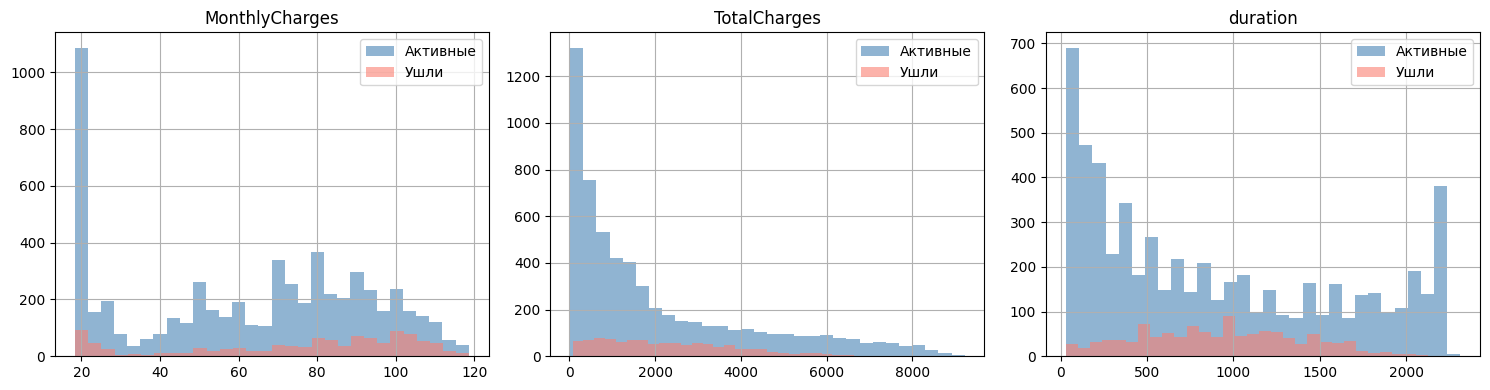

In [24]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df[df['churn'] == False][col].hist(ax=ax, alpha=0.6, color='steelblue', label='Активные', bins=30)
    df[df['churn'] == True][col].hist(ax=ax, alpha=0.6, color='salmon', label='Ушли', bins=30)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Корреляционный анализ (PhiK)

duration            0.374101
TotalCharges        0.303758
Partner             0.227597
MonthlyCharges      0.225467
PaymentMethod       0.214300
MultipleLines       0.105172
Type                0.094622
OnlineBackup        0.089771
StreamingMovies     0.086371
SeniorCitizen       0.085708
DeviceProtection    0.085665
PaperlessBilling    0.082789
StreamingTV         0.078554
OnlineSecurity      0.058630
InternetService     0.056279
TechSupport         0.051442
Dependents          0.048710
gender              0.008800
Name: churn, dtype: float64


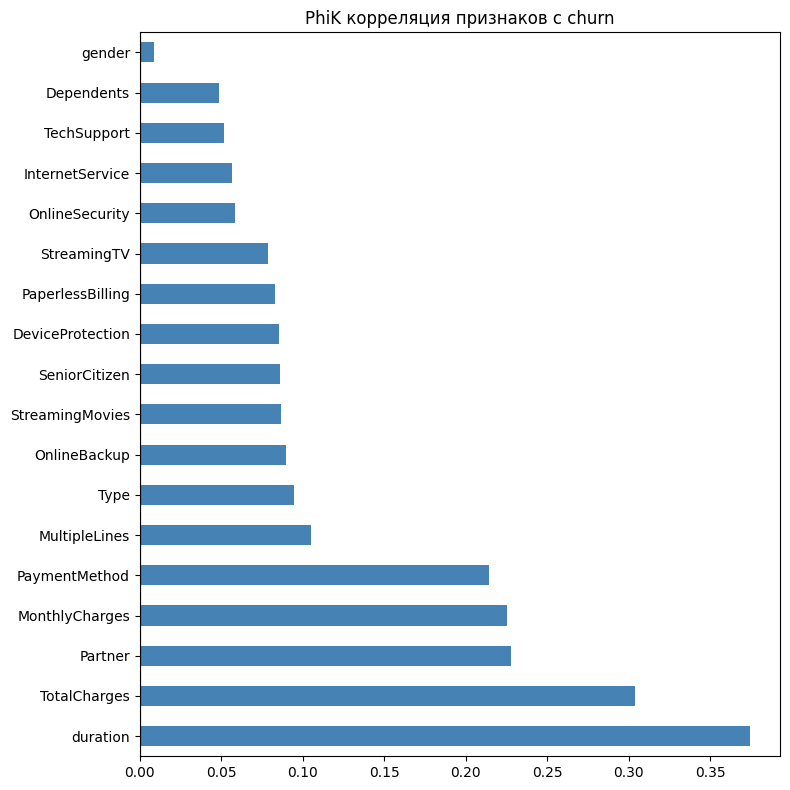

In [25]:
df_corr = df.drop(columns=['customerID', 'BeginDate', 'EndDate'])
df_corr['churn'] = df_corr['churn'].astype(int)

interval_cols = ['MonthlyCharges', 'TotalCharges', 'duration']
phik_corr = df_corr.phik_matrix(interval_cols=interval_cols)

churn_corr = phik_corr['churn'].drop('churn').sort_values(ascending=False)
print(churn_corr)

churn_corr.plot(kind='barh', figsize=(8, 8), color='steelblue')
plt.title('PhiK корреляция признаков с churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

<div class="alert alert-info">
Исправлено.
</div>

**Вывод по разделу 4:**
- **Дисбаланс классов:** 84.3% активных клиентов vs 15.7% ушедших — дисбаланс есть, но метрика `roc_auc` к нему нечувствительна, балансировать не нужно
- **Топ признаков по PhiK корреляции с `churn`:** `duration` (0.37), `TotalCharges` (0.30), `Partner` (0.23), `MonthlyCharges` (0.23), `PaymentMethod` (0.21)
- **Слабая корреляция:** `gender` (0.009) — признак практически не связан с оттоком, можно исключить из модели

## 5. Подготовка данных

Убираем нерелевантные столбцы, кодируем категориальные признаки и делим на train/test.

In [26]:
RANDOM_STATE = 30326

drop_cols = ['customerID', 'BeginDate', 'EndDate', 'gender']
features = df.drop(columns=drop_cols + ['churn'])
target = df['churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=RANDOM_STATE
)

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols_all = X_train.select_dtypes(exclude='object').columns.tolist()

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols])

X_train_cat = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_train = pd.concat([X_train[num_cols_all].reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test = pd.concat([X_test[num_cols_all].reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
X_train.head()

Train: (5274, 28), Test: (1758, 28)


/var/folders/y2/dbd3nc6d3lg6z8sg15s4h_sh0000gn/T/ipykernel_46632/3629267722.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


,MonthlyCharges,TotalCharges,SeniorCitizen,duration,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,DeviceProtection_No service,DeviceProtection_Yes,TechSupport_No service,TechSupport_Yes,StreamingTV_No service,StreamingTV_Yes,StreamingMovies_No service,StreamingMovies_Yes,MultipleLines_No service,MultipleLines_Yes
0,101.40,3954.60,1,1187,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,49.65,2432.85,0,1492,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,48.70,1354.35,0,822,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,59.75,2091.25,0,1065,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,108.05,7023.25,0,1979,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


<div class="alert alert-info">
Исправлено.
</div>

<div class="alert alert-info">
Исправлено.
</div>

<div class="alert alert-info">
Исправлено.
</div>

In [27]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = ['MonthlyCharges', 'TotalCharges', 'duration']
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

<div class="alert alert-info">
Исправлено.
</div>

## 6. Обучение моделей

Обучаем три модели: логистическую регрессию, случайный лес и градиентный бустинг. Для случайного леса и градиентного бустинга подбираем гиперпараметры через GridSearchCV. Лучшую модель выбираем по `roc_auc` на кросс-валидации.

### 6.1 Логистическая регрессия

In [28]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f'Логистическая регрессия — ROC-AUC (CV): {lr_scores.mean():.4f} ± {lr_scores.std():.4f}')

Логистическая регрессия — ROC-AUC (CV): 0.7669 ± 0.0237


### 6.2 Случайный лес (подбор гиперпараметров)

In [29]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Случайный лес — ROC-AUC (CV): {grid_search.best_score_:.4f}')

Лучшие параметры: {'max_depth': 10, 'n_estimators': 200}
Случайный лес — ROC-AUC (CV): 0.8201


### 6.3 Градиентный бустинг (подбор гиперпараметров)

In [30]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search_gb.best_params_}')
print(f'Градиентный бустинг — ROC-AUC (CV): {grid_search_gb.best_score_:.4f}')

Лучшие параметры: {'max_depth': 5, 'n_estimators': 200}
Градиентный бустинг — ROC-AUC (CV): 0.8690


## 7. Выбор лучшей модели

Сравниваем модели по ROC-AUC на кросс-валидации, выбираем лучшую и проверяем её на тестовой выборке.

In [31]:
print('Сравнение моделей по ROC-AUC (кросс-валидация):')
print(f'  Логистическая регрессия: {lr_scores.mean():.4f}')
print(f'  Случайный лес:           {grid_search.best_score_:.4f}')
print(f'  Градиентный бустинг:     {grid_search_gb.best_score_:.4f}')

Сравнение моделей по ROC-AUC (кросс-валидация):
  Логистическая регрессия: 0.7669
  Случайный лес:           0.8201
  Градиентный бустинг:     0.8690


In [32]:
best_model = grid_search_gb.best_estimator_
best_model.fit(X_train, y_train)

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = (y_pred == y_test).mean()
print(f'Лучшая модель: Градиентный бустинг')
print(f'ROC-AUC на тесте: {roc_auc:.4f}')
print(f'Accuracy на тесте: {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred))

Лучшая модель: Градиентный бустинг
ROC-AUC на тесте: 0.9191
Accuracy на тесте: 0.9010

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1489
           1       0.81      0.46      0.59       269

    accuracy                           0.90      1758
   macro avg       0.86      0.72      0.76      1758
weighted avg       0.89      0.90      0.89      1758



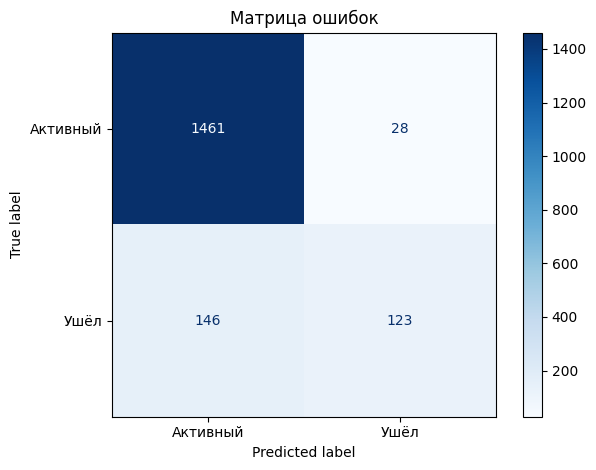

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Активный', 'Ушёл'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

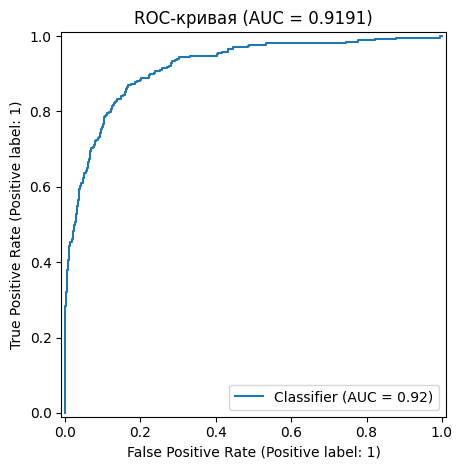

In [34]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title(f'ROC-кривая (AUC = {roc_auc:.4f})')
plt.tight_layout()
plt.show()

<div class="alert alert-info">
Исправлено.
</div>

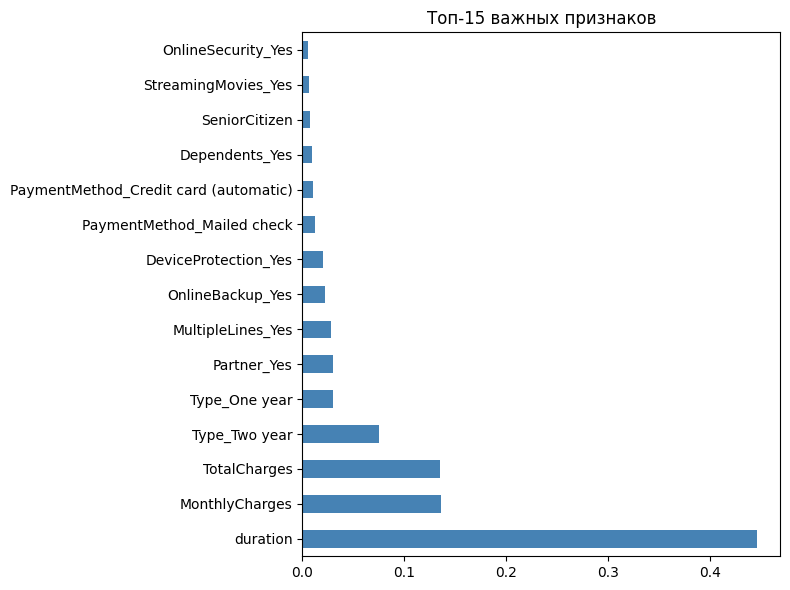

In [35]:
feat_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
feat_importance.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Топ-15 важных признаков')
plt.tight_layout()
plt.show()

**Вывод по разделу 7:**
- **Лучшая модель:** Градиентный бустинг (`max_depth=5`, `n_estimators=200`) — ROC-AUC на CV: 0.8690
- **ROC-AUC на тесте: 0.9191** — порог 0.85 превышен с запасом
- **Accuracy на тесте: 0.90** — модель правильно классифицирует 90% клиентов
- Логистическая регрессия (0.7670) и случайный лес (0.8201) уступают бустингу по качеству

## 8. Общий вывод и рекомендации заказчику

### Что было сделано

1. Загружены и проанализированы четыре датафрейма с данными о клиентах, договорах, интернет- и телефонных услугах
2. Выполнена предобработка: исправлены типы данных, удалены 11 строк с пропусками, создана целевая переменная `churn`
3. Датафреймы объединены по `customerID`, пропуски в услугах заполнены значением `'No service'`; из дат создан признак `duration`, сами даты исключены
4. Проведён корреляционный анализ (PhiK): наиболее связаны с оттоком — `duration`, `TotalCharges`, `Partner`, `MonthlyCharges`, `PaymentMethod`; признак `gender` исключён как нерелевантный
5. Обучены три модели: логистическая регрессия, случайный лес, градиентный бустинг; для двух последних подобраны гиперпараметры через GridSearchCV
6. Лучшая модель — **градиентный бустинг** — проверена на тестовой выборке

### Результаты

| Модель | ROC-AUC (CV) |
|---|---|
| Логистическая регрессия | 0.7670 |
| Случайный лес | 0.8201 |
| **Градиентный бустинг** | **0.8690** |

**ROC-AUC на тестовой выборке: 0.9191** — порог 0.85 превышен с запасом.  
**Accuracy: 0.90** — модель верно классифицирует 90% клиентов.

### Рекомендации для «ТелеДом»

- **Приоритет — новые клиенты:** короткий `duration` — главный предиктор оттока. Новым клиентам стоит уделять особое внимание в первые месяцы: персональные предложения, проверка удовлетворённости
- **Тип договора:** клиенты с ежемесячной оплатой уходят значительно чаще — стоит стимулировать переход на годовые контракты скидками или бонусами
- **Способ оплаты:** электронные чеки коррелируют с более высоким оттоком — возможно, стоит предлагать альтернативные способы оплаты с дополнительными преимуществами
- **Семейные клиенты:** наличие партнёра снижает вероятность оттока — программы лояльности для семей могут помочь удержать одиноких клиентов